# Regresión lineal simple y múltiple — chuleta explicada para examen

Este notebook está pensado para estudiar y copiar una estructura parecida en un examen.

Vamos a ver:

1. Qué es la regresión lineal.
2. Regresión lineal simple: una sola variable predictora.
3. Regresión lineal múltiple: varias variables predictoras.
4. División en entrenamiento y test.
5. Entrenamiento del modelo.
6. Evaluación con R², MAE, MSE y RMSE.
7. Predicción con datos nuevos.
8. Plantilla final para copiar en cualquier ejercicio.

## 1. Idea básica

La **regresión lineal** sirve para predecir un número.

Ejemplos:

- Predecir el precio de una casa.
- Predecir una nota.
- Predecir ventas.
- Predecir salario.

Hay dos tipos básicos:

### Regresión lineal simple

Usa **una sola variable** para predecir.

Ejemplo:

```text
Precio de una casa = depende solo de los ingresos medios
```

Fórmula:

```text
y = b0 + b1 · x
```

Donde:

- `y` es lo que queremos predecir.
- `x` es la variable que usamos para predecir.
- `b0` es el intercepto.
- `b1` es el coeficiente o pendiente.

### Regresión lineal múltiple

Usa **varias variables** para predecir.

Ejemplo:

```text
Precio de una casa = depende de ingresos, habitaciones, población, latitud, longitud...
```

Fórmula:

```text
y = b0 + b1·x1 + b2·x2 + b3·x3 + ...
```

## 2. Importar librerías

Estas librerías suelen aparecer siempre en ejercicios de regresión.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## 3. Cargar el dataset

Usamos el dataset `California Housing`.

El objetivo es predecir el valor medio de las viviendas.

La variable objetivo se llama `MedHouseVal`.

Las variables predictoras son las demás columnas.

In [2]:
# Cargamos los datos
housing = fetch_california_housing(as_frame=True)

# Convertimos los datos a un DataFrame
df = housing.frame

# Mostramos las primeras filas
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 4. Ver información básica del dataset

Antes de entrenar un modelo conviene mirar:

- cuántas filas y columnas hay;
- qué columnas existen;
- si hay valores nulos;
- estadísticas básicas.

In [3]:
# Tamaño del dataset
print("Filas y columnas:", df.shape)

# Información de columnas y tipos
df.info()

# Comprobar valores nulos
print("\nValores nulos por columna:")
print(df.isnull().sum())

# Estadísticas básicas
df.describe()

Filas y columnas: (20640, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

Valores nulos por columna:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


# PARTE A — Regresión lineal simple

En la regresión lineal simple usamos **una variable X** para predecir **una variable y**.

En este ejemplo:

```text
X = MedInc
y = MedHouseVal
```

Es decir, vamos a predecir el precio de la vivienda usando solo los ingresos medios.

## 5. Elegir X e y para regresión lineal simple

Importante:

- `X` debe tener forma de tabla, por eso usamos doble corchete: `df[['MedInc']]`.
- `y` es una sola columna, por eso usamos un corchete: `df['MedHouseVal']`.

In [4]:
# Variable predictora: ingresos medios
X_simple = df[['MedInc']]

# Variable objetivo: valor medio de la vivienda
y = df['MedHouseVal']

print("Forma de X_simple:", X_simple.shape)
print("Forma de y:", y.shape)

Forma de X_simple: (20640, 1)
Forma de y: (20640,)


## 6. Dividir en entrenamiento y test

Dividimos los datos:

- 80% para entrenar.
- 20% para probar.

El modelo aprende con `X_train` e `y_train`.

Luego comprobamos si predice bien usando `X_test` e `y_test`.

`random_state=42` sirve para que siempre salga la misma división.

In [5]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple,
    y,
    test_size=0.2,
    random_state=42
)

print("Entrenamiento:", X_train_s.shape)
print("Test:", X_test_s.shape)

Entrenamiento: (16512, 1)
Test: (4128, 1)


## 7. Crear y entrenar el modelo simple

Entrenar significa que el modelo calcula la recta que mejor se ajusta a los datos.

In [6]:
# Creamos el modelo
modelo_simple = LinearRegression()

# Entrenamos el modelo
modelo_simple.fit(X_train_s, y_train_s)

print("Intercepto b0:", modelo_simple.intercept_)
print("Coeficiente b1:", modelo_simple.coef_[0])

Intercepto b0: 0.44459729169078677
Coeficiente b1: 0.4193384939381274


## 8. Interpretar el modelo simple

La fórmula del modelo es:

```text
MedHouseVal = b0 + b1 · MedInc
```

Si el coeficiente `b1` es positivo, significa que cuando suben los ingresos medios, normalmente sube el valor de la vivienda.

Recuerda:

- `intercept_` es `b0`.
- `coef_` es `b1`.

In [7]:
print(f"Fórmula aproximada:")
print(f"MedHouseVal = {modelo_simple.intercept_:.4f} + {modelo_simple.coef_[0]:.4f} · MedInc")

Fórmula aproximada:
MedHouseVal = 0.4446 + 0.4193 · MedInc


## 9. Hacer predicciones con el modelo simple

Ahora usamos el conjunto de test para predecir.

El modelo no ha visto estos datos durante el entrenamiento, así que sirven para comprobar si generaliza bien.

In [8]:
y_pred_s = modelo_simple.predict(X_test_s)

# Mostramos algunas predicciones frente a valores reales
comparacion_simple = pd.DataFrame({
    "Valor real": y_test_s.values,
    "Predicción": y_pred_s
})

comparacion_simple.head(10)

,Valor real,Predicción
0,0.47700,1.149589
1,0.45800,1.506069
2,5.00001,1.903937
3,2.18600,2.850594
4,2.78000,2.006633
5,1.58700,2.421652
6,1.98200,2.576472
7,1.57500,1.992292
8,3.40000,2.458932
9,4.46600,3.846774


## 10. Evaluar el modelo simple

Usamos métricas:

### R²

Mide cuánto explica el modelo.

- Cerca de 1: muy bien.
- Cerca de 0: explica poco.
- Negativo: muy mal.

### MAE

Error absoluto medio.

Dice cuánto se equivoca el modelo de media.

### MSE

Error cuadrático medio.

Penaliza más los errores grandes.

### RMSE

Raíz del MSE.

Está en las mismas unidades que la variable objetivo, por eso es más fácil de interpretar.

In [9]:
r2_s = r2_score(y_test_s, y_pred_s)
mae_s = mean_absolute_error(y_test_s, y_pred_s)
mse_s = mean_squared_error(y_test_s, y_pred_s)
rmse_s = np.sqrt(mse_s)

print("MÉTRICAS REGRESIÓN SIMPLE")
print("R²:", round(r2_s, 4))
print("MAE:", round(mae_s, 4))
print("MSE:", round(mse_s, 4))
print("RMSE:", round(rmse_s, 4))

MÉTRICAS REGRESIÓN SIMPLE
R²: 0.4589
MAE: 0.6299
MSE: 0.7091
RMSE: 0.8421


## 11. Gráfico de regresión lineal simple

Como solo hay una variable predictora, podemos dibujar la recta.

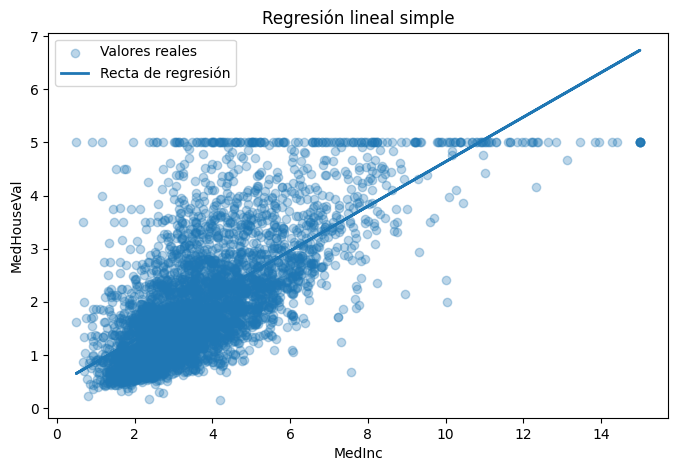

In [10]:
plt.figure(figsize=(8, 5))

plt.scatter(X_test_s, y_test_s, alpha=0.3, label="Valores reales")
plt.plot(X_test_s, y_pred_s, linewidth=2, label="Recta de regresión")

plt.xlabel("MedInc")
plt.ylabel("MedHouseVal")
plt.title("Regresión lineal simple")
plt.legend()
plt.show()

## 12. Predicción manual con un dato nuevo

Supongamos que queremos predecir el valor de una vivienda en una zona donde `MedInc = 5`.

Como la variable objetivo está en cientos de miles de dólares, si el resultado es `3.2`, significa aproximadamente:

```text
3.2 × 100000 = 320000 dólares
```

In [11]:
nuevo_dato_simple = pd.DataFrame({
    "MedInc": [5]
})

prediccion_simple = modelo_simple.predict(nuevo_dato_simple)

print("Predicción:", prediccion_simple[0])
print("Precio aproximado en dólares:", prediccion_simple[0] * 100000)

Predicción: 2.5412897613814236
Precio aproximado en dólares: 254128.97613814235


# PARTE B — Regresión lineal múltiple

En la regresión lineal múltiple usamos varias variables predictoras.

Ahora usamos todas las columnas menos `MedHouseVal` para predecir `MedHouseVal`.

## 13. Elegir X e y para regresión múltiple

Aquí `X` contiene todas las variables predictoras.

`y` sigue siendo la variable objetivo.

In [12]:
X_multiple = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

print("Columnas predictoras:")
print(X_multiple.columns.tolist())

print("\nForma de X_multiple:", X_multiple.shape)
print("Forma de y:", y.shape)

Columnas predictoras:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Forma de X_multiple: (20640, 8)
Forma de y: (20640,)


## 14. Dividir los datos en entrenamiento y test

Igual que antes:

- entrenamiento = aprender;
- test = comprobar.

In [13]:
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multiple,
    y,
    test_size=0.2,
    random_state=42
)

print("Entrenamiento:", X_train_m.shape)
print("Test:", X_test_m.shape)

Entrenamiento: (16512, 8)
Test: (4128, 8)


## 15. Crear y entrenar el modelo múltiple

El modelo buscará una ecuación de este tipo:

```text
MedHouseVal = b0 + b1·MedInc + b2·HouseAge + b3·AveRooms + ...
```

In [14]:
modelo_multiple = LinearRegression()

modelo_multiple.fit(X_train_m, y_train_m)

print("Intercepto b0:", modelo_multiple.intercept_)
print("Coeficientes:")
for nombre, coef in zip(X_multiple.columns, modelo_multiple.coef_):
    print(nombre, ":", coef)

Intercepto b0: -37.023277706064256
Coeficientes:
MedInc : 0.4486749096657182
HouseAge : 0.009724257517905063
AveRooms : -0.12332334282795991
AveBedrms : 0.783144906792973
Population : -2.029620580092512e-06
AveOccup : -0.0035263184871344028
Latitude : -0.41979248658836005
Longitude : -0.43370806496398817


## 16. Interpretar coeficientes

Cada coeficiente indica cómo cambia la predicción cuando esa variable aumenta una unidad, manteniendo las demás constantes.

Ejemplo:

- Si el coeficiente de `MedInc` es positivo, al aumentar los ingresos medios aumenta el precio estimado.
- Si un coeficiente es negativo, al aumentar esa variable baja la predicción.

Cuidado: en regresión múltiple no siempre es tan intuitivo porque las variables pueden estar relacionadas entre sí.

In [15]:
coeficientes = pd.DataFrame({
    "Variable": X_multiple.columns,
    "Coeficiente": modelo_multiple.coef_
})

coeficientes.sort_values(by="Coeficiente", ascending=False)

,Variable,Coeficiente
3,AveBedrms,0.783145
0,MedInc,0.448675
1,HouseAge,0.009724
4,Population,-0.000002
5,AveOccup,-0.003526
2,AveRooms,-0.123323
6,Latitude,-0.419792
7,Longitude,-0.433708


## 17. Hacer predicciones con el modelo múltiple

In [16]:
y_pred_m = modelo_multiple.predict(X_test_m)

comparacion_multiple = pd.DataFrame({
    "Valor real": y_test_m.values,
    "Predicción": y_pred_m
})

comparacion_multiple.head(10)

,Valor real,Predicción
0,0.47700,0.719123
1,0.45800,1.764017
2,5.00001,2.709659
3,2.18600,2.838926
4,2.78000,2.604657
5,1.58700,2.011754
6,1.98200,2.645500
7,1.57500,2.168755
8,3.40000,2.740746
9,4.46600,3.915615


## 18. Evaluar el modelo múltiple

Calculamos las mismas métricas que en la regresión simple.

In [17]:
r2_m = r2_score(y_test_m, y_pred_m)
mae_m = mean_absolute_error(y_test_m, y_pred_m)
mse_m = mean_squared_error(y_test_m, y_pred_m)
rmse_m = np.sqrt(mse_m)

print("MÉTRICAS REGRESIÓN MÚLTIPLE")
print("R²:", round(r2_m, 4))
print("MAE:", round(mae_m, 4))
print("MSE:", round(mse_m, 4))
print("RMSE:", round(rmse_m, 4))

MÉTRICAS REGRESIÓN MÚLTIPLE
R²: 0.5758
MAE: 0.5332
MSE: 0.5559
RMSE: 0.7456


## 19. Comparar regresión simple y múltiple

Normalmente la regresión múltiple mejora porque usa más información.

Pero no siempre: si metemos variables malas o mucho ruido, puede empeorar.

In [18]:
resultados = pd.DataFrame({
    "Modelo": ["Regresión simple", "Regresión múltiple"],
    "R2": [r2_s, r2_m],
    "MAE": [mae_s, mae_m],
    "RMSE": [rmse_s, rmse_m]
})

resultados

,Modelo,R2,MAE,RMSE
0,Regresión simple,0.458859,0.629909,0.842090
1,Regresión múltiple,0.575788,0.533200,0.745581


## 20. Conclusión típica para examen

Puedes escribir algo como esto:

```text
Comparando los modelos, el mejor será el que tenga mayor R² y menores errores MAE y RMSE.

En este caso, la regresión múltiple suele funcionar mejor que la simple porque utiliza más variables predictoras y, por tanto, tiene más información para estimar el valor de la vivienda.

La regresión simple es más fácil de interpretar, pero puede quedarse corta porque solo usa una variable.
```

## 21. Gráfico: valores reales vs predichos

Este gráfico sirve tanto para regresión simple como múltiple.

Si las predicciones fueran perfectas, los puntos estarían cerca de la línea diagonal.

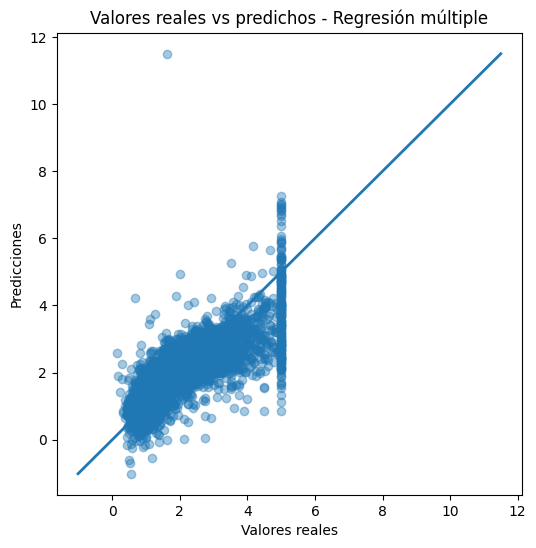

In [19]:
plt.figure(figsize=(6, 6))

plt.scatter(y_test_m, y_pred_m, alpha=0.4)

# Línea ideal: predicción perfecta
min_val = min(y_test_m.min(), y_pred_m.min())
max_val = max(y_test_m.max(), y_pred_m.max())
plt.plot([min_val, max_val], [min_val, max_val], linewidth=2)

plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Valores reales vs predichos - Regresión múltiple")
plt.show()

# PARTE C — R² ajustado

El R² normal puede subir simplemente por meter más variables.

Por eso en regresión múltiple se puede usar el **R² ajustado**, que penaliza meter variables innecesarias.

Fórmula:

```text
R2_ajustado = 1 - (1 - R2) · (n - 1) / (n - p - 1)
```

Donde:

- `n` = número de observaciones.
- `p` = número de variables predictoras.

In [20]:
def r2_ajustado(y_real, y_pred, num_variables):
    r2 = r2_score(y_real, y_pred)
    n = len(y_real)
    p = num_variables
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

r2_adj_simple = r2_ajustado(y_test_s, y_pred_s, X_test_s.shape[1])
r2_adj_multiple = r2_ajustado(y_test_m, y_pred_m, X_test_m.shape[1])

print("R² ajustado simple:", round(r2_adj_simple, 4))
print("R² ajustado múltiple:", round(r2_adj_multiple, 4))

R² ajustado simple: 0.4587
R² ajustado múltiple: 0.575


# PARTE D — Ejemplo sencillo inventado

Este ejemplo es más pequeño y sirve para entenderlo muy fácil.

Queremos predecir una nota final según las horas de estudio.

In [21]:
datos = pd.DataFrame({
    "horas_estudio": [1, 2, 3, 4, 5, 6, 7, 8],
    "nota": [2, 3, 4, 5, 6, 7, 8, 9]
})

datos

,horas_estudio,nota
0,1,2
1,2,3
2,3,4
3,4,5
4,5,6
5,6,7
6,7,8
7,8,9


In [22]:
X = datos[["horas_estudio"]]
y = datos["nota"]

modelo = LinearRegression()
modelo.fit(X, y)

print("Intercepto:", modelo.intercept_)
print("Coeficiente:", modelo.coef_[0])

nueva_persona = pd.DataFrame({"horas_estudio": [6.5]})
prediccion = modelo.predict(nueva_persona)

print("Si estudia 6.5 horas, nota estimada:", prediccion[0])

Intercepto: 0.9999999999999982
Coeficiente: 1.0000000000000004
Si estudia 6.5 horas, nota estimada: 7.500000000000001


# PARTE E — Plantilla para copiar en examen

Esta es la estructura más importante.

In [23]:
# 1. Importar librerías
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 2. Cargar datos
# df = pd.read_csv("archivo.csv")

# 3. Separar variables predictoras y objetivo
# Para regresión simple:
# X = df[["nombre_variable"]]

# Para regresión múltiple:
# X = df[["variable1", "variable2", "variable3"]]

# Variable objetivo:
# y = df["variable_objetivo"]

# 4. Dividir en entrenamiento y test
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )

# 5. Crear y entrenar el modelo
# modelo = LinearRegression()
# modelo.fit(X_train, y_train)

# 6. Predecir
# y_pred = modelo.predict(X_test)

# 7. Evaluar
# r2 = r2_score(y_test, y_pred)
# mae = mean_absolute_error(y_test, y_pred)
# mse = mean_squared_error(y_test, y_pred)
# rmse = np.sqrt(mse)

# print("R2:", r2)
# print("MAE:", mae)
# print("MSE:", mse)
# print("RMSE:", rmse)

# 8. Ver coeficientes
# print("Intercepto:", modelo.intercept_)
# print("Coeficientes:", modelo.coef_)

# PARTE F — Explicación escrita para poner en el examen

Puedes copiar esta explicación cuando te pregunten qué has hecho.

```text
Primero he separado el dataset en variables predictoras X y variable objetivo y.

Después he dividido los datos en conjunto de entrenamiento y conjunto de test. El conjunto de entrenamiento sirve para que el modelo aprenda y el conjunto de test sirve para evaluar si el modelo predice bien con datos nuevos.

A continuación he creado un modelo de regresión lineal con LinearRegression y lo he entrenado usando fit(X_train, y_train).

Después he realizado predicciones sobre X_test usando predict().

Finalmente he evaluado el modelo con R², MAE, MSE y RMSE.

R² indica qué parte de la variabilidad de la variable objetivo explica el modelo. Cuanto más cerca de 1, mejor.

MAE mide el error medio absoluto. Cuanto más bajo, mejor.

MSE mide el error cuadrático medio y penaliza más los errores grandes.

RMSE es la raíz del MSE y se interpreta en las mismas unidades que la variable objetivo.

Si comparo varios modelos, elegiré como mejor modelo el que tenga mayor R² y menores valores de MAE y RMSE.
```

# PARTE G — Diferencia entre simple y múltiple

```text
La regresión lineal simple usa una sola variable predictora para estimar la variable objetivo.

La regresión lineal múltiple usa varias variables predictoras para estimar la variable objetivo.

La simple es más fácil de interpretar, pero puede quedarse corta.

La múltiple suele predecir mejor porque utiliza más información, aunque hay que tener cuidado con incluir variables irrelevantes.
```

# PARTE H — Frases rápidas para memorizar

```text
X son las variables que uso para predecir.
y es la variable que quiero predecir.

fit() entrena el modelo.
predict() hace predicciones.

train_test_split divide los datos en entrenamiento y prueba.

R² cuanto más alto mejor.
MAE, MSE y RMSE cuanto más bajos mejor.

El intercepto es el valor de y cuando todas las X valen 0.
Los coeficientes indican cuánto cambia y cuando cambia una variable X.
```